# 07 - LSTM Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {device}")

Device: mps


## 1. Load and Prepare Data

In [2]:
data = pd.read_parquet(PROCESSED / 'modeling_data.parquet')
data['decision_date'] = pd.to_datetime(data['decision_date'])
data = data.sort_values(['symbol', 'decision_date']).reset_index(drop=True)

# 6-class target (same as 06b)
label_map_9_to_6 = {0:0, 1:1, 2:1, 3:2, 4:3, 5:3, 6:4, 7:5, 8:5}
label_to_bucket_6 = {0:'ATM_SHORT', 1:'ATM_LONG', 2:'OTM5_SHORT', 3:'OTM5_LONG', 4:'OTM10_SHORT', 5:'OTM10_LONG'}

data['label_6'] = data['label'].map(label_map_9_to_6)

# Feature pruning (same as 06b — drop price-level and correlated features)
drop_features = ['adjusted_close', 'volume', 'operating_margin', 'price_to_sma50', 'vol_10d']
exclude_cols = ['symbol', 'decision_date', 'year_month', 'label', 'best_bucket',
                'best_return', 'fiscalDateEnding', 'year', 'label_6']

feature_cols = [c for c in data.columns if c not in exclude_cols and c not in drop_features]
data[feature_cols] = data[feature_cols].fillna(data[feature_cols].median())

print(f"Data: {data.shape[0]} rows, {len(feature_cols)} features")
print(f"Features: {feature_cols}")
print(f"\n6-class distribution:")
print(data['label_6'].value_counts().sort_index())

Data: 1391 rows, 25 features
Features: ['vol_21d', 'vol_63d', 'mom_5d', 'mom_21d', 'mom_63d', 'price_to_sma21', 'price_to_sma200', 'sma21_above_sma50', 'sma50_above_sma200', 'drawdown_63d', 'drawdown_252d', 'volume_ratio', 'high_vol_regime', 'gross_margin', 'net_margin', 'revenue_growth_yoy', 'earnings_growth_yoy', 'debt_to_equity', 'cash_ratio', 'roe', 'roa', 'pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield']

6-class distribution:
label_6
0    256
1    429
2     90
3    272
4     97
5    247
Name: count, dtype: int64


## 2. Create Sequences

In [3]:
def create_sequences(data, feature_cols, target_col, seq_length):
    X_seq, y_seq, meta = [], [], []
    for symbol in data['symbol'].unique():
        sym_data = data[data['symbol'] == symbol].sort_values('decision_date')
        features = sym_data[feature_cols].values
        labels = sym_data[target_col].values
        dates = sym_data['decision_date'].values
        for i in range(seq_length, len(sym_data)):
            X_seq.append(features[i-seq_length:i])
            y_seq.append(labels[i])
            meta.append({'symbol': symbol, 'date': dates[i]})
    return np.array(X_seq), np.array(y_seq), meta

# We'll search over sequence lengths later; start with 4
SEQ_LENGTH = 4
X_seq, y_seq, meta = create_sequences(data, feature_cols, 'label_6', SEQ_LENGTH)
print(f"Sequences: {X_seq.shape}  (samples, timesteps, features)")

Sequences: (1351, 4, 25)  (samples, timesteps, features)


In [4]:
# Single stratified split — reused for both single and two-stage models
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_seq, y_seq, meta, test_size=0.2, random_state=SEED, stratify=y_seq
)

# Scale features
n_train, seq_len, n_feat = X_train.shape
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(n_train, seq_len, n_feat)
X_test_sc = scaler.transform(X_test.reshape(-1, n_feat)).reshape(len(X_test), seq_len, n_feat)

# Derive moneyness/maturity from 6-class label
moneyness_map = {0:0, 1:0, 2:1, 3:1, 4:2, 5:2}  # ATM=0, OTM5=1, OTM10=2
maturity_map = {0:0, 1:1, 2:0, 3:1, 4:0, 5:1}    # SHORT=0, LONG=1

y_train_money = np.array([moneyness_map[y] for y in y_train])
y_test_money = np.array([moneyness_map[y] for y in y_test])
y_train_mat = np.array([maturity_map[y] for y in y_train])
y_test_mat = np.array([maturity_map[y] for y in y_test])

print(f"Train: {n_train}, Test: {len(X_test)}")
print(f"Moneyness train dist: {np.bincount(y_train_money)}")
print(f"Maturity train dist: {np.bincount(y_train_mat)}")

Train: 1080, Test: 271
Moneyness train dist: [540 278 262]
Maturity train dist: [351 729]


## 3. LSTM with Temporal Attention

In [5]:
class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, bidirectional=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        lstm_out_size = hidden_size * self.directions

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_size, lstm_out_size // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_size // 2, 1)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (batch, seq, hidden*directions)

        # Attention weights
        attn_scores = self.attention(lstm_out).squeeze(-1)  # (batch, seq)
        attn_weights = torch.softmax(attn_scores, dim=1)    # (batch, seq)

        # Weighted sum
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)  # (batch, hidden*dir)

        return self.classifier(context)

print("AttentionLSTM defined")

AttentionLSTM defined


## 4. Training Utilities

In [6]:
def make_loaders(X_train_sc, y_train, X_test_sc, y_test, batch_size=32):
    train_ds = TensorDataset(torch.FloatTensor(X_train_sc), torch.LongTensor(y_train))
    test_ds = TensorDataset(torch.FloatTensor(X_test_sc), torch.LongTensor(y_test))
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            DataLoader(test_ds, batch_size=batch_size, shuffle=False))

def train_and_evaluate(X_train_sc, X_test_sc, y_train, y_test, num_classes,
                       hidden_size=32, num_layers=1, dropout=0.4, lr=0.001,
                       epochs=150, patience=20, verbose=True):
    train_loader, test_loader = make_loaders(X_train_sc, y_train, X_test_sc, y_test)

    model = AttentionLSTM(
        input_size=X_train_sc.shape[2], hidden_size=hidden_size,
        num_layers=num_layers, num_classes=num_classes, dropout=dropout
    ).to(device)

    # Class weights
    counts = np.bincount(y_train, minlength=num_classes).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    weights = weights / weights.sum() * num_classes
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(weights).to(device))
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1, best_state, wait = 0, None, 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)
        scheduler.step()
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['train_acc'].append(correct / total)

        # Eval
        model.eval()
        val_loss, preds, labels = 0, [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()
                preds.extend(out.argmax(1).cpu().numpy())
                labels.extend(yb.cpu().numpy())
        preds, labels = np.array(preds), np.array(labels)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_acc'].append(accuracy_score(labels, preds))
        history['val_f1'].append(f1_score(labels, preds, average='macro'))

        if history['val_f1'][-1] > best_f1:
            best_f1 = history['val_f1'][-1]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if verbose and ((epoch+1) % 25 == 0 or epoch == 0):
            print(f"  Epoch {epoch+1:3d} | TrainAcc={history['train_acc'][-1]:.3f} | "
                  f"ValAcc={history['val_acc'][-1]:.3f} | ValF1={history['val_f1'][-1]:.3f}")

        if wait >= patience:
            if verbose: print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds.extend(model(xb).argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())

    return model, np.array(preds), np.array(labels), best_f1, history

print("Training utilities defined")

Training utilities defined


## 5. Sequence Length Search

In [7]:
# Find optimal sequence length
seq_results = {}
for sl in [3, 4, 6, 8]:
    print(f"\nSequence length = {sl}")
    X_s, y_s, _ = create_sequences(data, feature_cols, 'label_6', sl)
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=SEED, stratify=y_s)
    n_tr = X_tr.shape[0]
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr.reshape(-1, n_feat)).reshape(n_tr, sl, n_feat)
    X_te_sc = sc.transform(X_te.reshape(-1, n_feat)).reshape(len(X_te), sl, n_feat)

    _, _, _, f1, _ = train_and_evaluate(
        X_tr_sc, X_te_sc, y_tr, y_te, num_classes=6,
        hidden_size=32, num_layers=1, dropout=0.4, epochs=100, patience=15, verbose=False
    )
    seq_results[sl] = f1
    print(f"  Best Val F1: {f1:.4f}")

best_seq = max(seq_results, key=seq_results.get)
print(f"\nBest sequence length: {best_seq} (F1={seq_results[best_seq]:.4f})")


Sequence length = 3


  Best Val F1: 0.3671

Sequence length = 4


  Best Val F1: 0.3330

Sequence length = 6


  Best Val F1: 0.3224

Sequence length = 8


  Best Val F1: 0.3443

Best sequence length: 3 (F1=0.3671)


## 6. Train Final 6-Class Model

In [8]:
# Rebuild sequences with best length
X_seq, y_seq, meta = create_sequences(data, feature_cols, 'label_6', best_seq)
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_seq, y_seq, meta, test_size=0.2, random_state=SEED, stratify=y_seq
)

n_train, seq_len, n_feat = X_train.shape
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(n_train, seq_len, n_feat)
X_test_sc = scaler.transform(X_test.reshape(-1, n_feat)).reshape(len(X_test), seq_len, n_feat)

# Derive sub-targets from same split
y_train_money = np.array([moneyness_map[y] for y in y_train])
y_test_money = np.array([moneyness_map[y] for y in y_test])
y_train_mat = np.array([maturity_map[y] for y in y_train])
y_test_mat = np.array([maturity_map[y] for y in y_test])

print(f"Final sequences: {X_seq.shape}")
print(f"Train: {n_train}, Test: {len(X_test)}")

Final sequences: (1361, 3, 25)
Train: 1088, Test: 273


In [9]:
print("Training 6-class LSTM...")
model_6, preds_6, labels_6, f1_6, hist_6 = train_and_evaluate(
    X_train_sc, X_test_sc, y_train, y_test, num_classes=6,
    hidden_size=32, num_layers=1, dropout=0.4, lr=0.001,
    epochs=150, patience=20, verbose=True
)

acc_6 = accuracy_score(labels_6, preds_6)
f1m_6 = f1_score(labels_6, preds_6, average='macro')
f1w_6 = f1_score(labels_6, preds_6, average='weighted')

print(f"\n6-Class LSTM Results:")
print(f"  Accuracy:    {acc_6:.4f}")
print(f"  Macro F1:    {f1m_6:.4f}")
print(f"  Weighted F1: {f1w_6:.4f}")
print(classification_report(labels_6, preds_6, target_names=[label_to_bucket_6[i] for i in range(6)]))

Training 6-class LSTM...


  Epoch   1 | TrainAcc=0.136 | ValAcc=0.154 | ValF1=0.103


  Epoch  25 | TrainAcc=0.411 | ValAcc=0.359 | ValF1=0.316


  Epoch  50 | TrainAcc=0.512 | ValAcc=0.355 | ValF1=0.329


  Epoch  75 | TrainAcc=0.562 | ValAcc=0.377 | ValF1=0.349


  Early stop at epoch 84

6-Class LSTM Results:
  Accuracy:    0.3846
  Macro F1:    0.3636
  Weighted F1: 0.3899
              precision    recall  f1-score   support

   ATM_SHORT       0.28      0.31      0.29        51
    ATM_LONG       0.57      0.48      0.52        85
  OTM5_SHORT       0.33      0.28      0.30        18
   OTM5_LONG       0.29      0.37      0.32        52
 OTM10_SHORT       0.37      0.37      0.37        19
  OTM10_LONG       0.39      0.35      0.37        48

    accuracy                           0.38       273
   macro avg       0.37      0.36      0.36       273
weighted avg       0.40      0.38      0.39       273



## 7. Two-Stage LSTM (Same Split)

In [10]:
print("Training Stage 1 — Moneyness (3-class)...")
money_model, money_preds, money_labels, money_f1, _ = train_and_evaluate(
    X_train_sc, X_test_sc, y_train_money, y_test_money, num_classes=3,
    hidden_size=32, num_layers=1, dropout=0.4, epochs=150, patience=20, verbose=True
)
print(f"  Moneyness F1: {money_f1:.4f}")
print(classification_report(money_labels, money_preds, target_names=['ATM', 'OTM5', 'OTM10']))

print("\nTraining Stage 2 — Maturity (2-class)...")
mat_model, mat_preds, mat_labels, mat_f1, _ = train_and_evaluate(
    X_train_sc, X_test_sc, y_train_mat, y_test_mat, num_classes=2,
    hidden_size=32, num_layers=1, dropout=0.4, epochs=150, patience=20, verbose=True
)
print(f"  Maturity F1: {mat_f1:.4f}")
print(classification_report(mat_labels, mat_preds, target_names=['SHORT', 'LONG']))

Training Stage 1 — Moneyness (3-class)...


  Epoch   1 | TrainAcc=0.295 | ValAcc=0.359 | ValF1=0.314


  Epoch  25 | TrainAcc=0.669 | ValAcc=0.546 | ValF1=0.531


  Epoch  50 | TrainAcc=0.769 | ValAcc=0.535 | ValF1=0.508


  Early stop at epoch 53
  Moneyness F1: 0.5651
              precision    recall  f1-score   support

         ATM       0.69      0.65      0.67       136
        OTM5       0.42      0.49      0.45        70
       OTM10       0.58      0.57      0.58        67

    accuracy                           0.59       273
   macro avg       0.57      0.57      0.57       273
weighted avg       0.60      0.59      0.59       273


Training Stage 2 — Maturity (2-class)...


  Epoch   1 | TrainAcc=0.647 | ValAcc=0.645 | ValF1=0.549


  Epoch  25 | TrainAcc=0.736 | ValAcc=0.641 | ValF1=0.604


  Epoch  50 | TrainAcc=0.869 | ValAcc=0.652 | ValF1=0.596


  Early stop at epoch 58
  Maturity F1: 0.6488
              precision    recall  f1-score   support

       SHORT       0.52      0.55      0.53        88
        LONG       0.78      0.76      0.77       185

    accuracy                           0.69       273
   macro avg       0.65      0.65      0.65       273
weighted avg       0.69      0.69      0.69       273



In [11]:
# Combine: moneyness * 2 + maturity = 6-class
y_pred_2s = money_preds * 2 + mat_preds
y_true_2s = y_test_money * 2 + y_test_mat

acc_2s = accuracy_score(y_true_2s, y_pred_2s)
f1_2s = f1_score(y_true_2s, y_pred_2s, average='macro')
f1w_2s = f1_score(y_true_2s, y_pred_2s, average='weighted')

print(f"Two-Stage LSTM (6-class combined):")
print(f"  Accuracy:    {acc_2s:.4f}")
print(f"  Macro F1:    {f1_2s:.4f}")
print(f"  Weighted F1: {f1w_2s:.4f}")
print(classification_report(y_true_2s, y_pred_2s, target_names=[label_to_bucket_6[i] for i in range(6)]))

Two-Stage LSTM (6-class combined):
  Accuracy:    0.4212
  Macro F1:    0.3839
  Weighted F1: 0.4220
              precision    recall  f1-score   support

   ATM_SHORT       0.46      0.35      0.40        51
    ATM_LONG       0.58      0.60      0.59        85
  OTM5_SHORT       0.23      0.39      0.29        18
   OTM5_LONG       0.32      0.31      0.31        52
 OTM10_SHORT       0.35      0.42      0.38        19
  OTM10_LONG       0.36      0.31      0.33        48

    accuracy                           0.42       273
   macro avg       0.38      0.40      0.38       273
weighted avg       0.43      0.42      0.42       273



## 8. Training Curves & Confusion Matrices

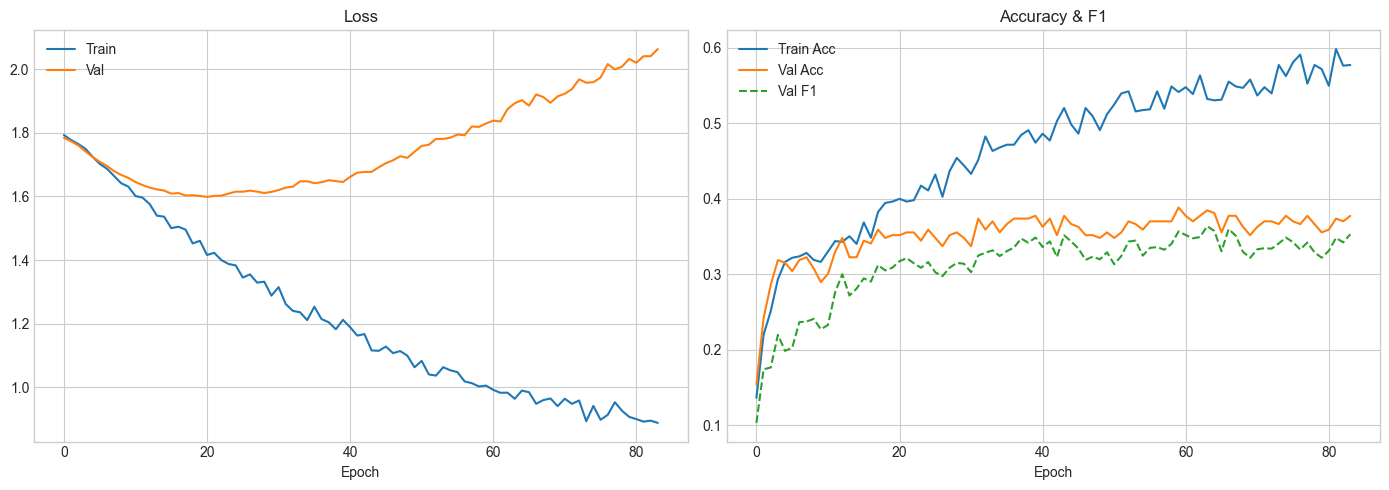

In [12]:
# Training curves for 6-class model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_6['train_loss'], label='Train')
axes[0].plot(hist_6['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].set_xlabel('Epoch')
axes[1].plot(hist_6['train_acc'], label='Train Acc')
axes[1].plot(hist_6['val_acc'], label='Val Acc')
axes[1].plot(hist_6['val_f1'], label='Val F1', linestyle='--')
axes[1].set_title('Accuracy & F1')
axes[1].legend()
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_training_curves.png', dpi=150)
plt.show()

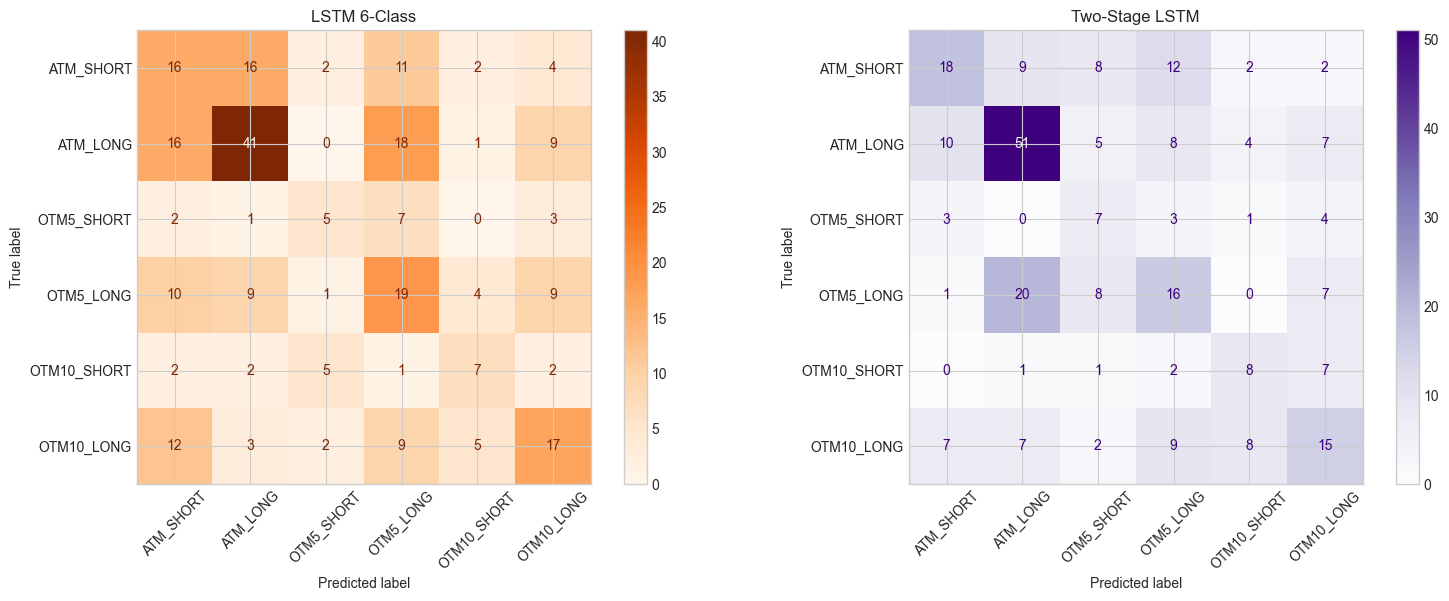

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm1 = confusion_matrix(labels_6, preds_6)
disp1 = ConfusionMatrixDisplay(cm1, display_labels=[label_to_bucket_6[i] for i in range(6)])
disp1.plot(ax=axes[0], cmap='Oranges', values_format='d')
axes[0].set_title('LSTM 6-Class')
axes[0].tick_params(axis='x', rotation=45)

cm2 = confusion_matrix(y_true_2s, y_pred_2s)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=[label_to_bucket_6[i] for i in range(6)])
disp2.plot(ax=axes[1], cmap='Purples', values_format='d')
axes[1].set_title('Two-Stage LSTM')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/lstm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Full Model Comparison

Full Model Comparison:
                     Model  Accuracy  Macro F1
     9-class RF (baseline)  0.333300  0.310300
    9-class XGB (baseline)  0.274100  0.249000
  6-class RF (tuned+SMOTE)  0.465900  0.401800
 6-class XGB (tuned+SMOTE)  0.494600  0.422200
6-class LGBM (tuned+SMOTE)  0.480300  0.406700
         6-class Two-Stage  0.835100  0.816500
  LSTM 6-class (attention)  0.384615  0.363612
Two-Stage LSTM (attention)  0.421245  0.383887


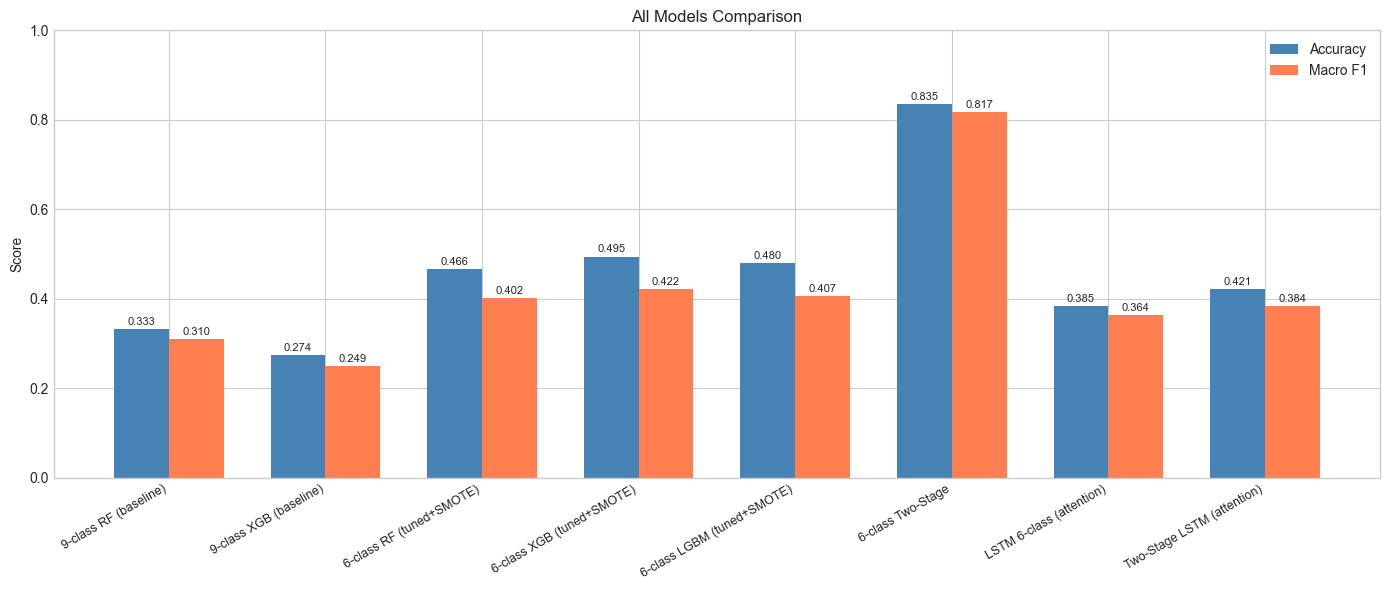

In [14]:
# Load previous results
prev = pd.read_csv(PROCESSED / 'improved_results.csv')

# Add LSTM results
lstm_rows = pd.DataFrame({
    'Model': ['LSTM 6-class (attention)', 'Two-Stage LSTM (attention)'],
    'Accuracy': [acc_6, acc_2s],
    'Macro F1': [f1m_6, f1_2s]
})
all_results = pd.concat([prev, lstm_rows], ignore_index=True)

print("Full Model Comparison:")
print(all_results.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_results))
w = 0.35
b1 = ax.bar(x - w/2, all_results['Accuracy'], w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, all_results['Macro F1'], w, label='Macro F1', color='coral')
ax.set_xticks(x); ax.set_xticklabels(all_results['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_title('All Models Comparison'); ax.legend(); ax.set_ylim(0, 1)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Models

In [15]:
# Save LSTM models
torch.save({
    'model_state_dict': model_6.state_dict(),
    'input_size': n_feat, 'hidden_size': 32, 'num_layers': 1,
    'num_classes': 6, 'seq_length': best_seq, 'feature_cols': feature_cols,
}, MODELS / 'lstm_6class.pt')

torch.save({'model_state_dict': money_model.state_dict(),
            'num_classes': 3, 'task': 'moneyness'}, MODELS / 'lstm_moneyness.pt')
torch.save({'model_state_dict': mat_model.state_dict(),
            'num_classes': 2, 'task': 'maturity'}, MODELS / 'lstm_maturity.pt')

# Save combined results
all_results.to_csv(PROCESSED / 'all_model_results.csv', index=False)

print("All models and results saved.")
best = all_results.loc[all_results['Macro F1'].idxmax()]
print(f"\nBest overall: {best['Model']} (Macro F1: {best['Macro F1']:.4f})")

All models and results saved.

Best overall: 6-class Two-Stage (Macro F1: 0.8165)
